# HexCNN explicada paso a paso

Notebook didactico para entender **como funciona la CNN hexagonal** del TFM:
como se mete el grafo de vecindad, como se hace la convolucion sobre la malla,
y como crece el campo receptivo con la profundidad.

Idea clave: cada SiPM es un **nodo** de un grafo. La HexCNN propaga informacion
entre sensores que **fisicamente comparten luz** (vecinos en la malla hexagonal).
No hay imagenes ni pixeles: hay 61 nodos y sus aristas.

> Ejecuta las celdas en orden. Necesita `psipm.tsv` (ruta por defecto en `hex_geometry.DEFAULT_PSIPM`).

## 1. Cargar el codigo del proyecto y la geometria

Importamos las utilidades del repo y construimos la **matriz de vecindad** `nbr`
de forma `(61, 6)`: `nbr[i, k] = j` significa *"el k-esimo vecino del sensor i es el sensor j"*;
un `-1` indica que ahi no hay vecino (sensores de borde con menos de 6).

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# Aseguramos que se importa el codigo del proyecto (este notebook vive en la carpeta del codigo)
CODE_DIR = Path.cwd()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from dataset import load_positions, N_ACTIVE, IDX_TO_ICH
from hex_geometry import get_neighbor_matrix, DEFAULT_PSIPM
from model import HexConv, HexResBlock, HexCNNImputer, count_parameters

nbr = get_neighbor_matrix()                 # (61, 6) grafo de vecindad real
x_sipm, y_sipm = load_positions(DEFAULT_PSIPM)

print('Matriz de vecindad :', nbr.shape)
print('Posiciones (x, y)  :', x_sipm.shape, y_sipm.shape)
print('Sensores activos   :', N_ACTIVE)
print('\nFila nbr[30] (vecinos del nodo 30):', nbr[30])
print(nbr)


Matriz de vecindad : (61, 6)
Posiciones (x, y)  : (61,) (61,)
Sensores activos   : 61

Fila nbr[30] (vecinos del nodo 30): [38 28 16 33 31 15]
[[10 11 59 49 12 58]
 [25 56  5 27 23 55]
 [59  6 11 35  8  9]
 [18 22 21 -1 -1 -1]
 [11  7  6 14 49 53]
 [26 58 12  1 25 56]
 [ 2 13  4  9 11  7]
 [ 4 13 14  6 -1 -1]
 [21 35 22 59 20  2]
 [35  6  2 13 -1 -1]
 [28  0 20 12 15 59]
 [ 0  4  2 49 59  6]
 [10  5 28  0 26 58]
 [ 6  7  9 -1 -1 -1]
 [ 7 52  4 53 -1 -1]
 [16 20 28 19 30 10]
 [31 15 30 29 32 19]
 [24 23 37 27 -1 -1]
 [ 3 19 29 21 -1 -1]
 [29 21 18 15 16 20]
 [15 59 21 10 19  8]
 [19  8 20  3 18 22]
 [ 3  8 21 35 -1 -1]
 [37 27 17 25 41  1]
 [17 54 27 -1 -1 -1]
 [41  1 26 23 39  5]
 [39  5 25 33 12 28]
 [23 55 24  1 17 54]
 [30 10 15 33 12 26]
 [32 19 16 18 -1 -1]
 [38 28 16 33 31 15]
 [34 16 38 32 36 30]
 [29 31 34 16 -1 -1]
 [30 39 38 28 40 26]
 [31 36 32 -1 -1 -1]
 [ 8  9  2 22 -1 -1]
 [38 34 42 31 -1 -1]
 [43 23 41 17 -1 -1]
 [36 30 31 33 42 40]
 [40 26 33 41 25 45]
 [44 39 45 33 42 

## 2. Visualizar la malla y los vecinos de un sensor

Pintamos los 61 SiPM en sus posiciones reales y resaltamos en rojo las aristas
del sensor `FOCUS` hacia sus vecinos. Esas aristas son **exactamente** las que
usa la HexConv para agregar informacion.

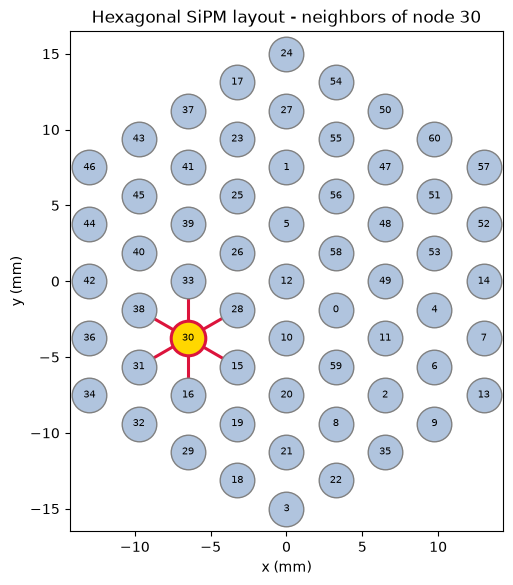

Vecinos densos de 30 -> [38, 28, 16, 33, 31, 15]


In [2]:
FOCUS = 30   # indice denso (0..60) del sensor que inspeccionamos

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(x_sipm, y_sipm, s=620, c='lightsteelblue', edgecolors='gray', zorder=2)
for i in range(N_ACTIVE):
    ax.annotate(str(i), (x_sipm[i], y_sipm[i]), ha='center', va='center', fontsize=7, zorder=3)

# aristas FOCUS -> vecinos
for j in nbr[FOCUS]:
    if j >= 0:
        ax.plot([x_sipm[FOCUS], x_sipm[j]], [y_sipm[FOCUS], y_sipm[j]],
                color='crimson', lw=2.2, zorder=1)
ax.scatter(x_sipm[FOCUS], y_sipm[FOCUS], s=620, c='gold', edgecolors='crimson', lw=2.2, zorder=2)

ax.set_aspect('equal')
ax.set_title(f'Hexagonal SiPM layout - neighbors of node {FOCUS}')
ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.show()

print('Vecinos densos de', FOCUS, '->', [int(j) for j in nbr[FOCUS] if j >= 0])

In [3]:
# Cuantos vecinos tiene cada sensor (interiores = 6, borde < 6)
n_neigh = (nbr >= 0).sum(axis=1)
print('Vecinos por sensor : min=%d  max=%d  media=%.2f' % (n_neigh.min(), n_neigh.max(), n_neigh.mean()))
print('Interiores (6)     :', int((n_neigh == 6).sum()))
print('Borde (<6)         :', int((n_neigh < 6).sum()))

Vecinos por sensor : min=3  max=6  media=5.11
Interiores (6)     : 37
Borde (<6)         : 24


## 3. Una HexConv "a mano" (numpy)

Aqui esta el corazon de todo. Una HexConv hace, para cada nodo:

$$\text{out}_i = W_{self}\, x_i \;+\; W_{neigh}\, \underbrace{\frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} x_j}_{\text{media de vecinos}}$$

El truco fino es como se calcula esa **media de vecinos** sin bucles y respetando
que los sensores de borde tienen menos de 6 vecinos. Se hace con el **nodo de padding**:

1. Anadimos un nodo extra (indice `N=61`) lleno de ceros.
2. Los huecos `-1` de `nbr` se redirigen a ese nodo de ceros.
3. Recogemos los 6 vecinos de cada nodo de golpe (indexado avanzado).
4. Promediamos **solo** sobre los vecinos reales (una mascara anula el padding).

Lo replicamos en numpy con una feature por nodo para verlo claro:

In [ ]:
N = N_ACTIVE
# Senal de juguete: 1 feature por nodo. Valores distintos (1..61) para seguir la cuenta.
x = np.arange(1, N + 1, dtype=np.float32).reshape(N, 1)        # (61, 1)

# 1) nodo de padding: fila de ceros al final -> indice N (=61)
x_pad = np.concatenate([x, np.zeros((1, 1), np.float32)], axis=0)   # (62, 1)

# 2) huecos (-1) -> apuntan al nodo de padding
gather_idx = np.where(nbr >= 0, nbr, N)                         # (61, 6)

# 3) recoger los 6 vecinos de cada nodo (indexado avanzado)
nb = x_pad[gather_idx]                                          # (61, 6, 1)

# 4) media SOLO sobre vecinos reales
valid = (nbr >= 0).astype(np.float32)[..., None]               # (61, 6, 1)
nb_mean = (nb * valid).sum(1) / np.clip(valid.sum(1), 1, None) # (61, 1)

print('Nodo', FOCUS, '-> valor propio:', float(x[FOCUS, 0]))
print('  vecinos (idx):', [int(j) for j in nbr[FOCUS] if j >= 0])
print('  vecinos (val):', [float(x[j, 0]) for j in nbr[FOCUS] if j >= 0])
print('  media (vectorizada):', float(nb_mean[FOCUS, 0]))
print('  media (a mano)     :', float(np.mean([x[j, 0] for j in nbr[FOCUS] if j >= 0])))
print(nbr)


Nodo 30 -> valor propio: 31.0
  vecinos (idx): [38, 28, 16, 33, 31, 15]
  vecinos (val): [39.0, 29.0, 17.0, 34.0, 32.0, 16.0]
  media (vectorizada): 27.83333396911621
  media (a mano)     : 27.83333396911621
[[[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [0.]
  [0.]
  [0.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [0.]
  [0.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [0.]
  [0.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [0.]
  [0.]
  [0.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [0.]
  [0.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]
  [0.]
  [0.]]



La media vectorizada coincide con la cuenta a mano. Eso es lo unico "magico"
de la HexConv; el resto son dos `Linear` (uno al nodo, otro a la media de vecinos)
+ BatchNorm + GELU. Ahora usamos la capa **real** del proyecto:

In [10]:
torch.manual_seed(0)
conv = HexConv(in_f=1, out_f=4, neighbor_matrix=nbr).eval()

xt = torch.from_numpy(x)[None]            # (1, 61, 1) -> (batch, nodos, features)
with torch.no_grad():
    out = conv(xt)

print('HexConv  entrada', tuple(xt.shape), '-> salida', tuple(out.shape))
print('Parametros de HexConv(1->4):', count_parameters(conv))
print('  lin_self : 1*4 + 4 (bias) = 8')
print('  lin_neigh: 1*4           = 4   (sin bias)')
print('  batchnorm: 4 + 4         = 8')

HexConv  entrada (1, 61, 1) -> salida (1, 61, 4)
Parametros de HexConv(1->4): 20
  lin_self : 1*4 + 4 (bias) = 8
  lin_neigh: 1*4           = 4   (sin bias)
  batchnorm: 4 + 4         = 8


## 4. Campo receptivo: por que la profundidad importa

Cada HexConv propaga informacion **1 anillo** (1 salto). Un `HexResBlock` tiene
**2 HexConv** = 2 saltos, y el modelo usa **4 bloques = 8 saltos**.

Simulamos cuantos sensores "alcanza" la informacion partiendo del nodo `FOCUS`
tras 1, 2, 4 y 8 saltos. Veras que con 8 saltos **ya se cubre el detector entero**:
por eso el cuello de botella del modelo actual no es la profundidad, sino el **ancho**
(solo 48 canales).

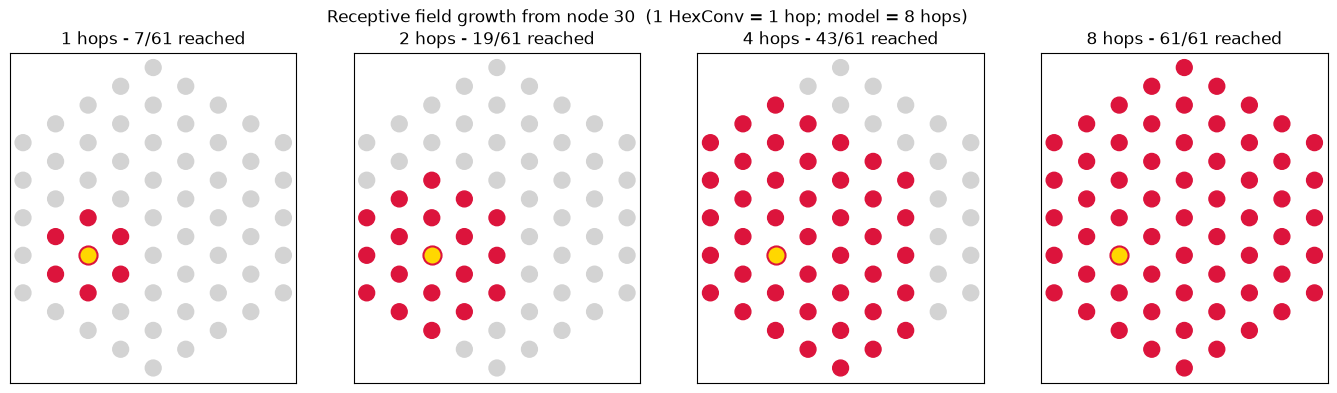

In [11]:
# Matriz de adyacencia binaria y simetrica a partir de nbr
A = np.zeros((N, N), np.float32)
for i in range(N):
    for j in nbr[i]:
        if j >= 0:
            A[i, j] = 1.0
            A[j, i] = 1.0

def reach_after(hops, src):
    """Sensores alcanzados desde 'src' tras 'hops' saltos."""
    r = np.zeros(N, dtype=bool)
    r[src] = True
    for _ in range(hops):
        r = r | (A @ r > 0)
    return r

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
for ax, h in zip(axes, [1, 2, 4, 8]):
    r = reach_after(h, FOCUS)
    ax.scatter(x_sipm, y_sipm, s=130, c=np.where(r, 'crimson', 'lightgray'))
    ax.scatter(x_sipm[FOCUS], y_sipm[FOCUS], s=170, c='gold', edgecolors='crimson', lw=1.5)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{h} hops - {int(r.sum())}/{N} reached')
fig.suptitle(f'Receptive field growth from node {FOCUS}  (1 HexConv = 1 hop; model = 8 hops)')
plt.show()

## 5. El modelo completo: HexCNNImputer

Juntamos todo. El flujo es:

```
(B, 2, 61)                      entrada: [carga normalizada, mascara]
  -> permute -> (B, 61, 2)      formato "por nodo"
  -> Stem  Linear(2->48)+BN+GELU -> (B, 61, 48)
  -> 4x HexResBlock              x + [HexConv -> Dropout -> HexConv]
  -> Head  Linear(48->1)         -> (B, 61, 1)
  -> squeeze                     -> (B, 61)   cargas reconstruidas
```

Hacemos un forward de juguete y trazamos las formas etapa por etapa:

In [12]:
model = HexCNNImputer(hidden=48, n_blocks=4).eval()
print('HexCNNImputer  parametros entrenables:', f'{count_parameters(model):,}')

B = 8
xb = torch.randn(B, 2, N_ACTIVE)          # batch de juguete (carga + mascara)

with torch.no_grad():
    h = xb.permute(0, 2, 1);                                            print('permute   ', tuple(h.shape))
    h = torch.nn.functional.gelu(
            model.stem_bn(model.stem(h).reshape(B * N, -1)).reshape(B, N, -1)); print('stem      ', tuple(h.shape))
    for k, blk in enumerate(model.blocks):
        h = blk(h);                                                     print(f'block {k}   ', tuple(h.shape))
    out = model.head(h).squeeze(-1);                                    print('head      ', tuple(out.shape))

# Comprobacion: el forward oficial da lo mismo
with torch.no_grad():
    print('\nforward() oficial ->', tuple(model(xb).shape))

HexCNNImputer  parametros entrenables: 38,305
permute    (8, 61, 2)
stem       (8, 61, 48)
block 0    (8, 61, 48)
block 1    (8, 61, 48)
block 2    (8, 61, 48)
block 3    (8, 61, 48)
head       (8, 61)

forward() oficial -> (8, 61)


## 6. Comparativa de tamano de las tres arquitecturas

Para tener la foto de capacidad (es el eje del barrido que estamos discutiendo):

In [13]:
from model import get_model

for name in ('deepmlp', 'resmlp', 'hexcnn'):
    m = get_model(name)
    print(f'{name:9s} | parametros: {count_parameters(m):>9,}')

# HexCNN a distintos anchos (lo que proponemos escalar)
print('\nHexCNN escalando el ancho:')
for hidden, nb_ in [(48, 4), (96, 6), (128, 6)]:
    m = HexCNNImputer(hidden=hidden, n_blocks=nb_)
    print(f'  hidden={hidden:3d} n_blocks={nb_} | parametros: {count_parameters(m):>9,}')

deepmlp   | parametros:   500,541
resmlp    | parametros:   345,981
hexcnn    | parametros:    38,305

HexCNN escalando el ancho:
  hidden= 48 n_blocks=4 | parametros:    38,305
  hidden= 96 n_blocks=6 | parametros:   225,217
  hidden=128 n_blocks=6 | parametros:   398,593


## Resumen

- El **grafo** entra como `nbr` (61x6): para cada sensor, quienes son sus vecinos fisicos.
- Una **HexConv** = transformar el nodo + transformar la **media de sus vecinos**, con pesos
  compartidos por los 61 nodos (eso la hace "convolucion").
- El **nodo de padding** resuelve elegantemente los sensores de borde (<6 vecinos).
- La **profundidad** controla el campo receptivo: 8 saltos ya cubren el detector,
  asi que para ganar capacidad conviene escalar el **ancho** (`hidden`).
- La HexCNN gana a resmlp/deepmlp con **muchos menos parametros** gracias a este prior geometrico.